# Graph Attention Networks: Transductive + Inductive Experiments

This notebook runs:

- **Transductive node classification:** Cora, CiteSeer, PubMed
- **Inductive node classification:** PPI
- **Charts:** validation curves and final result comparison

Paper reference: Veličković et al., *Graph Attention Networks*, arXiv:1710.10903.

> Runtime recommendation: `Runtime > Change runtime type > T4 GPU` or better.


In [ ]:
# ============================================================
# 1. Install dependencies
# ============================================================
# Run this once after opening the notebook in Colab.

import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch-geometric', 'scikit-learn'])
else:
    print('Not running in Colab. Make sure torch_geometric and scikit-learn are installed.')


In [ ]:
# ============================================================
# 2. User-editable Drive path
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/CS4782/Final Project/CS4782FinalProjectGraphAttention'

import os
from pathlib import Path

PROJECT_DIR = Path(PROJECT_DIR)
print('PROJECT_DIR =', PROJECT_DIR)
print('Exists:', PROJECT_DIR.exists())
print('Contents:')
if PROJECT_DIR.exists():
    for p in sorted(PROJECT_DIR.iterdir()):
        print(' -', p.name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR = /content/drive/MyDrive/CS4782/Final Project/CS4782FinalProjectGraphAttention
Exists: True
Contents:
 - .git
 - .gitignore
 - CS4782_GAT_Paper_Reimplementation.ipynb
 - GCN.py
 - MLP.py
 - README.md
 - data
 - data_preprocessing.py
 - gat_browser_only_drive_mount_colab_sparse_fix.ipynb
 - models
 - test.py
 - utils


In [ ]:
# ============================================================
# 3. Import your existing code from Drive
# ============================================================

import os
import sys
import shutil
from pathlib import Path

PROJECT_DIR = Path(PROJECT_DIR)
assert PROJECT_DIR.exists(), f'PROJECT_DIR does not exist: {PROJECT_DIR}'

RUNTIME_IMPORT_ROOT = Path('/content/gat_runtime_imports')
RUNTIME_IMPORT_ROOT.mkdir(exist_ok=True)

models_src = None
if (PROJECT_DIR / 'models').exists():
    models_src = PROJECT_DIR / 'models'
else:
    raise FileNotFoundError('Could not find either models/ or model/ inside PROJECT_DIR')

utils_src = PROJECT_DIR / 'utils'
if not utils_src.exists():
    raise FileNotFoundError('Could not find utils/ inside PROJECT_DIR')

for link_name, src in [('models', models_src), ('utils', utils_src)]:
    dst = RUNTIME_IMPORT_ROOT / link_name
    if dst.exists() or dst.is_symlink():
        if dst.is_symlink() or dst.is_file():
            dst.unlink()
        else:
            shutil.rmtree(dst)
    os.symlink(src, dst)

# Add project root and runtime import root to sys.paths
for p in [str(RUNTIME_IMPORT_ROOT), str(PROJECT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from models.gat import GAT
from models.sp_gat import SpGAT
from models.base_gattn import BaseGAttN
from utils.layers import AttentionHead, SpAttentionHead

print('Imported GAT from:', GAT)
print('Imported SpGAT from:', SpGAT)
print('Runtime package root:', RUNTIME_IMPORT_ROOT)


Imported GAT from: <class 'models.gat.GAT'>
Imported SpGAT from: <class 'models.sp_gat.SpGAT'>
Runtime package root: /content/gat_runtime_imports


In [ ]:
# ============================================================
# 4. Imports, device, reproducibility, memory cleanup
# ============================================================

import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, PPI
from torch_geometric.utils import add_self_loops
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


device = cuda
Tesla T4


## 6. Configuration

The transductive settings follow the common GAT paper-style setup: 8 hidden attention heads with 8 features each, dropout 0.6, ELU hidden activations, and masked cross entropy on train/validation/test masks.

For PPI, the full paper-style architecture is:

- 3 total GAT layers
- First two layers: 4 attention heads, 256 features per head
- Final layer: 6 attention heads averaged into multilabel logits
- BCE-with-logits loss and micro-F1 evaluation

The paper reports about **0.973 micro-F1** for PPI. Reproducing this exactly can vary by implementation, seed, GPU, sparse vs dense implementation, and early stopping behavior.


In [33]:
# ============================================================
# 5. Experiment config
# ============================================================

DATA_ROOT = PROJECT_DIR / 'data'
if not DATA_ROOT.exists():
    DATA_ROOT = Path('/content/data')
print('DATA_ROOT =', DATA_ROOT)

RUN_TRANSDUCTIVE_DATASETS = ['Cora', 'CiteSeer', 'PubMed']
RUN_PPI = True

TRANSDUCTIVE_EPOCHS = 1000
TRANSDUCTIVE_PATIENCE = 100

PPI_EPOCHS = 1000
PPI_PATIENCE = 150

# If True, runs the paper-scale PPI architecture. If Colab OOMs, set to False for a smoke test.
FULL_PAPER_PPI = True

TRANSDUCTIVE_CONFIGS = {
    'Cora': dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=5e-4, residual=False, use_sparse=False),
    'CiteSeer': dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=5e-4, residual=False, use_sparse=False),
    'PubMed': dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6, lr=0.005, weight_decay=1e-3, residual=False, use_sparse=True),
}

PPI_FULL_CONFIG = dict(
    # 2 hidden layers + 1 output layer = 3 total GAT layers.
    hid_units=[256, 256],
    n_heads=[4, 4, 6],
    attn_drop=0.0,
    ffd_drop=0.0,
    lr=0.005,
    weight_decay=0.0,
    residual=True,
    use_sparse=True,
    batch_size=1,
)

PPI_SMOKE_CONFIG = dict(
    hid_units=[16],
    n_heads=[4, 1],
    attn_drop=0.2,
    ffd_drop=0.2,
    lr=0.005,
    weight_decay=0.0,
    residual=True,
    use_sparse=True,
    batch_size=1,
)

PPI_CONFIG = PPI_FULL_CONFIG if FULL_PAPER_PPI else PPI_SMOKE_CONFIG


DATA_ROOT = /content/drive/MyDrive/CS4782/Final Project/CS4782FinalProjectGraphAttention/data


In [ ]:
# ============================================================
# 6. Graph helpers
# ============================================================

def preprocess_features(x):
    rowsum = x.sum(dim=1, keepdim=True).clamp(min=1e-9)
    return x / rowsum


def load_planetoid_dataset(name):
    dataset = Planetoid(root=str(DATA_ROOT), name=name)
    data = dataset[0]
    data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    data.x = preprocess_features(data.x)
    return dataset, data


def edge_index_to_bias(edge_index, num_nodes, device):
    bias = torch.full((1, num_nodes, num_nodes), -1e9, device=device)
    edge_index = edge_index.to(device)
    bias[0, edge_index[0], edge_index[1]] = 0.0
    return bias


def edge_index_to_sparse_adj(edge_index, num_nodes, device):
    edge_index = edge_index.to(device)
    values = torch.ones(edge_index.shape[1], device=device)
    return torch.sparse_coo_tensor(edge_index, values, (num_nodes, num_nodes), device=device).coalesce()


def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()


def make_transductive_model(dataset, data, cfg):
    if cfg['use_sparse']:
        return SpGAT(
            in_features=dataset.num_features,
            nb_classes=dataset.num_classes,
            nb_nodes=data.num_nodes,
            hid_units=cfg['hid_units'],
            n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'],
            ffd_drop=cfg['ffd_drop'],
            residual=cfg['residual'],
        ).to(device)
    return GAT(
        in_features=dataset.num_features,
        nb_classes=dataset.num_classes,
        hid_units=cfg['hid_units'],
        n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'],
        ffd_drop=cfg['ffd_drop'],
        residual=cfg['residual'],
    ).to(device)


In [ ]:
# ============================================================
# 7. Train/evaluate transductive datasets
# ============================================================

def forward_transductive(model, data, cfg):
    x = data.x.to(device).unsqueeze(0)
    if cfg['use_sparse']:
        adj = edge_index_to_sparse_adj(data.edge_index, data.num_nodes, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(data.edge_index, data.num_nodes, device)
    return model(x, bias).squeeze(0)


def evaluate_transductive(model, data, cfg, mask):
    model.eval()
    with torch.no_grad():
        logits = forward_transductive(model, data, cfg)
        y = data.y.to(device)
        mask = mask.to(device)
        loss = F.cross_entropy(logits[mask], y[mask]).item()
        acc = accuracy_from_logits(logits[mask], y[mask])
    return loss, acc


def train_transductive_dataset(dataset_name):
    cleanup_cuda()
    dataset, data = load_planetoid_dataset(dataset_name)
    cfg = TRANSDUCTIVE_CONFIGS[dataset_name]
    model = make_transductive_model(dataset, data, cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    y = data.y.to(device)
    train_mask = data.train_mask.to(device)

    best_val_acc = -1.0
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, TRANSDUCTIVE_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        logits = forward_transductive(model, data, cfg)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        train_loss, train_acc = evaluate_transductive(model, data, cfg, data.train_mask)
        val_loss, val_acc = evaluate_transductive(model, data, cfg, data.val_mask)
        test_loss, test_acc = evaluate_transductive(model, data, cfg, data.test_mask)

        history.append(dict(
            dataset=dataset_name,
            epoch=epoch,
            train_loss=train_loss,
            train_acc=train_acc,
            val_loss=val_loss,
            val_acc=val_acc,
            test_loss=test_loss,
            test_acc=test_acc,
        ))

        if epoch == 1 or epoch % 25 == 0:
            print(f'{dataset_name:8s} | epoch {epoch:04d} | loss {train_loss:.4f} | val_acc {val_acc:.4f} | test_acc {test_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if patience >= TRANSDUCTIVE_PATIENCE:
            print(f'{dataset_name}: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    final_train_loss, final_train_acc = evaluate_transductive(model, data, cfg, data.train_mask)
    final_val_loss, final_val_acc = evaluate_transductive(model, data, cfg, data.val_mask)
    final_test_loss, final_test_acc = evaluate_transductive(model, data, cfg, data.test_mask)

    print(f'FINAL {dataset_name}: val_acc={final_val_acc:.4f}, test_acc={final_test_acc:.4f}')
    cleanup_cuda()
    return model, pd.DataFrame(history), dict(dataset=dataset_name, val_acc=final_val_acc, test_acc=final_test_acc)


In [ ]:
# ============================================================
# 8. Run transductive experiments
# ============================================================

transductive_histories = []
transductive_results = []

for dataset_name in RUN_TRANSDUCTIVE_DATASETS:
    model, hist, result = train_transductive_dataset(dataset_name)
    transductive_histories.append(hist)
    transductive_results.append(result)
    del model
    cleanup_cuda()

transductive_history_df = pd.concat(transductive_histories, ignore_index=True)
transductive_results_df = pd.DataFrame(transductive_results)
transductive_results_df


Cora     | epoch 0001 | loss 1.9448 | val_acc 0.2360 | test_acc 0.2000
Cora     | epoch 0025 | loss 1.8958 | val_acc 0.5600 | test_acc 0.5370
Cora     | epoch 0050 | loss 1.7729 | val_acc 0.6380 | test_acc 0.6460
Cora     | epoch 0075 | loss 1.5751 | val_acc 0.7360 | test_acc 0.7520
Cora     | epoch 0100 | loss 1.3543 | val_acc 0.7740 | test_acc 0.7800
Cora     | epoch 0125 | loss 1.1820 | val_acc 0.7840 | test_acc 0.7940
Cora     | epoch 0150 | loss 1.0540 | val_acc 0.7980 | test_acc 0.8010
Cora     | epoch 0175 | loss 0.9654 | val_acc 0.7920 | test_acc 0.8040
Cora     | epoch 0200 | loss 0.9048 | val_acc 0.8000 | test_acc 0.8100
Cora: early stopping at epoch 207
FINAL Cora: val_acc=0.8140, test_acc=0.8200
CiteSeer | epoch 0001 | loss 1.7911 | val_acc 0.2500 | test_acc 0.2420
CiteSeer | epoch 0025 | loss 1.7634 | val_acc 0.5820 | test_acc 0.5990
CiteSeer | epoch 0050 | loss 1.6988 | val_acc 0.6440 | test_acc 0.6510
CiteSeer | epoch 0075 | loss 1.5818 | val_acc 0.6680 | test_acc 0.6660

,dataset,val_acc,test_acc
0,Cora,0.814,0.820
1,CiteSeer,0.738,0.718
2,PubMed,0.816,0.777


In [28]:
# ============================================================
# 9. PPI helpers: full paper-style inductive training
# ============================================================

def make_ppi_model(sample, cfg):
    nb_classes = sample.y.shape[-1]
    if cfg['use_sparse']:
        return SpGAT(
            in_features=sample.num_node_features,
            nb_classes=nb_classes,
            nb_nodes=sample.num_nodes,
            hid_units=cfg['hid_units'],
            n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'],
            ffd_drop=cfg['ffd_drop'],
            residual=cfg['residual'],
        ).to(device)
    return GAT(
        in_features=sample.num_node_features,
        nb_classes=nb_classes,
        hid_units=cfg['hid_units'],
        n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'],
        ffd_drop=cfg['ffd_drop'],
        residual=cfg['residual'],
    ).to(device)


def forward_ppi(model, batch, cfg):
    batch = batch.to(device)
    x = batch.x.unsqueeze(0)
    N = batch.num_nodes
    if cfg['use_sparse']:
        model.nb_nodes = N
        adj = edge_index_to_sparse_adj(batch.edge_index, N, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(batch.edge_index, N, device)
    return model(x, bias).squeeze(0)


def ppi_micro_f1_from_logits(logits_list, labels_list):
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
    gold = labels.int().cpu().numpy()
    return f1_score(gold, preds, average='micro')


def evaluate_ppi(model, loader, cfg):
    model.eval()
    losses = []
    logits_list = []
    labels_list = []
    criterion = torch.nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in loader:
            logits = forward_ppi(model, batch, cfg)
            labels = batch.y.to(device).float()
            loss = criterion(logits, labels)
            losses.append(loss.item())
            logits_list.append(logits.detach().cpu())
            labels_list.append(labels.detach().cpu())

    return float(np.mean(losses)), ppi_micro_f1_from_logits(logits_list, labels_list)


def train_ppi_fullpaper():
    cleanup_cuda()
    ppi_train = PPI(root=str(DATA_ROOT / 'PPI'), split='train')
    ppi_val = PPI(root=str(DATA_ROOT / 'PPI'), split='val')
    ppi_test = PPI(root=str(DATA_ROOT / 'PPI'), split='test')

    cfg = PPI_CONFIG
    train_loader = DataLoader(ppi_train, batch_size=cfg['batch_size'], shuffle=True)
    val_loader = DataLoader(ppi_val, batch_size=1, shuffle=False)
    test_loader = DataLoader(ppi_test, batch_size=1, shuffle=False)

    model = make_ppi_model(ppi_train[0], cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_f1 = -1.0
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, PPI_EPOCHS + 1):
        model.train()
        batch_losses = []

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = forward_ppi(model, batch, cfg)
            loss = criterion(logits, batch.y.float())
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_loss, val_f1 = evaluate_ppi(model, val_loader, cfg)

        history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss, val_micro_f1=val_f1))

        if epoch == 1 or epoch % 10 == 0:
            print(f'PPI | epoch {epoch:04d} | train_loss {train_loss:.4f} | val_f1 {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if patience >= PPI_PATIENCE:
            print(f'PPI: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    test_loss, test_f1 = evaluate_ppi(model, test_loader, cfg)
    print(f'FINAL PPI: val_micro_f1={best_val_f1:.4f}, test_micro_f1={test_f1:.4f}')

    cleanup_cuda()
    return model, pd.DataFrame(history), dict(dataset='PPI', val_micro_f1=best_val_f1, test_micro_f1=test_f1)


In [29]:
# ============================================================
# 10. Run PPI inductive experiment
# ============================================================

if RUN_PPI:
    ppi_model, ppi_history_df, ppi_result = train_ppi_fullpaper()
    display(pd.DataFrame([ppi_result]))
else:
    ppi_history_df = pd.DataFrame()
    ppi_result = None


PPI | epoch 0001 | train_loss 0.6200 | val_f1 0.4760
PPI | epoch 0010 | train_loss 0.4269 | val_f1 0.6293
PPI | epoch 0020 | train_loss 0.3135 | val_f1 0.7289
PPI | epoch 0030 | train_loss 0.2567 | val_f1 0.7797
PPI | epoch 0040 | train_loss 0.2144 | val_f1 0.8040
PPI | epoch 0050 | train_loss 0.1762 | val_f1 0.8421
PPI | epoch 0060 | train_loss 0.1525 | val_f1 0.8526
PPI | epoch 0070 | train_loss 0.1668 | val_f1 0.8036
PPI | epoch 0080 | train_loss 0.1176 | val_f1 0.8880
PPI | epoch 0090 | train_loss 0.1081 | val_f1 0.8865
PPI | epoch 0100 | train_loss 0.0910 | val_f1 0.8941
PPI | epoch 0110 | train_loss 0.1076 | val_f1 0.8938
PPI | epoch 0120 | train_loss 0.0961 | val_f1 0.8927
PPI | epoch 0130 | train_loss 0.0529 | val_f1 0.9175
PPI | epoch 0140 | train_loss 0.0642 | val_f1 0.9198
PPI | epoch 0150 | train_loss 0.0979 | val_f1 0.8782
PPI | epoch 0160 | train_loss 0.0759 | val_f1 0.8947
PPI | epoch 0170 | train_loss 0.0371 | val_f1 0.9351
PPI | epoch 0180 | train_loss 0.1530 | val_f1 

,dataset,val_micro_f1,test_micro_f1
0,PPI,0.952433,0.969972


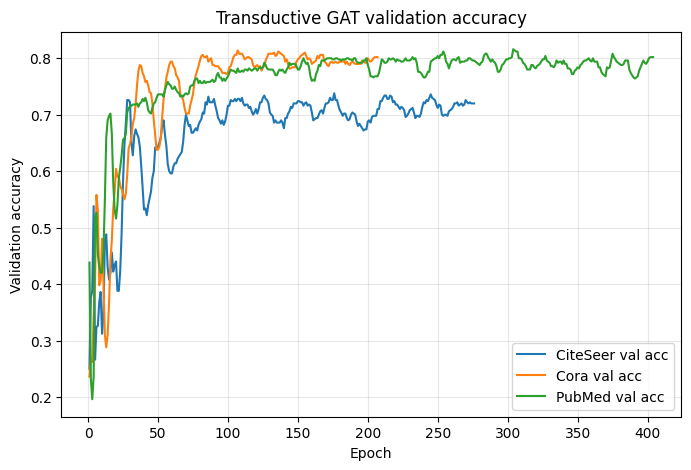

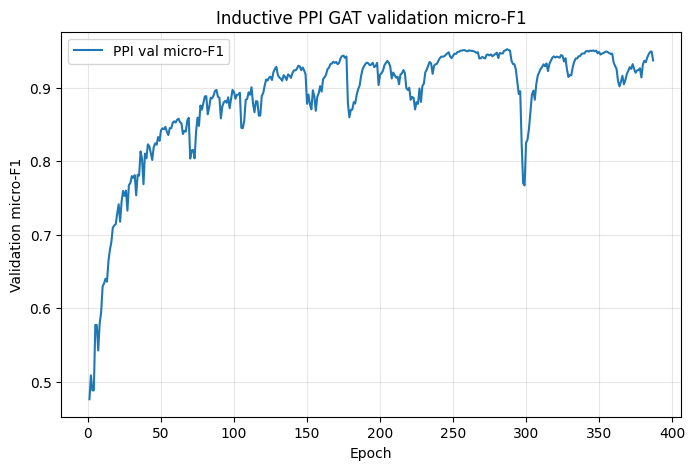

In [31]:
# ============================================================
# 11. Plot learning curves
# ============================================================

# Transductive validation accuracy curves
plt.figure(figsize=(8, 5))
for dataset_name, group in transductive_history_df.groupby('dataset'):
    plt.plot(group['epoch'], group['val_acc'], label=f'{dataset_name} val acc')
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Transductive GAT validation accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# PPI validation micro-F1 curve
if RUN_PPI and not ppi_history_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(ppi_history_df['epoch'], ppi_history_df['val_micro_f1'], label='PPI val micro-F1')
    plt.xlabel('Epoch')
    plt.ylabel('Validation micro-F1')
    plt.title('Inductive PPI GAT validation micro-F1')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


,dataset,setting,metric,score,paper_target_approx
0,Cora,transductive,test accuracy,0.820000,0.830
1,CiteSeer,transductive,test accuracy,0.718000,0.725
2,PubMed,transductive,test accuracy,0.777000,0.790
3,PPI,inductive,test micro-F1,0.969972,0.973


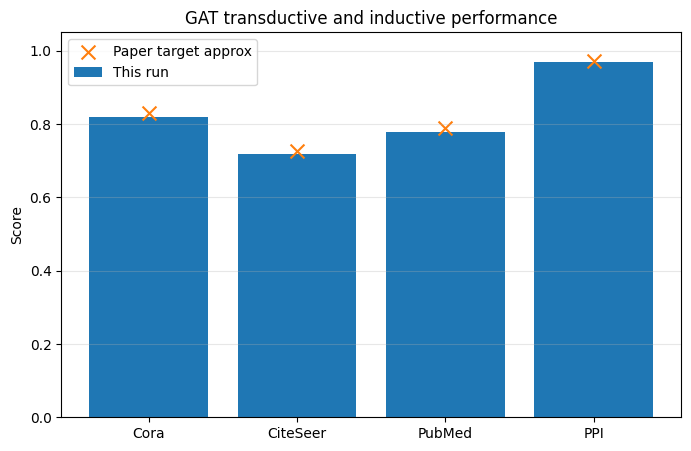

In [32]:
# ============================================================
# 12. Final comparison table + bar chart
# ============================================================

summary_rows = []
for row in transductive_results:
    summary_rows.append({
        'dataset': row['dataset'],
        'setting': 'transductive',
        'metric': 'test accuracy',
        'score': row['test_acc'],
        'paper_target_approx': {'Cora': 0.83, 'CiteSeer': 0.725, 'PubMed': 0.79}.get(row['dataset'], np.nan),
    })

if RUN_PPI and ppi_result is not None:
    summary_rows.append({
        'dataset': 'PPI',
        'setting': 'inductive',
        'metric': 'test micro-F1',
        'score': ppi_result['test_micro_f1'],
        'paper_target_approx': 0.973,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

plt.figure(figsize=(8, 5))
plt.bar(summary_df['dataset'], summary_df['score'], label='This run')
plt.scatter(summary_df['dataset'], summary_df['paper_target_approx'], marker='x', s=100, label='Paper target approx')
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('GAT transductive and inductive performance')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()


## Notes for interpreting results

Expected paper-style target ranges:

| Dataset | Setting | Metric | Approx. target |
|---|---:|---:|---:|
| Cora | transductive | accuracy | ~0.83 |
| CiteSeer | transductive | accuracy | ~0.72 |
| PubMed | transductive | accuracy | ~0.79 |
| PPI | inductive | micro-F1 | ~0.973 |
